In [81]:
from pathlib import Path
import sys

ROOT = Path().resolve().parent
sys.path.append(str(ROOT))

from scraper.database import get_engine, getData
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [82]:
engine = get_engine()

In [83]:
print(engine)

Engine(mssql+pyodbc:///?odbc_connect=DRIVER%3D%7BODBC+Driver+17+for+SQL+Server%7D%3BSERVER%3Dlocalhost%3BDATABASE%3DDelhaize%3BTrusted_Connection%3Dyes%3BTrustServerCertificate%3Dyes%3B)


In [84]:
df_products = getData(engine, query="SELECT * FROM Products")
df_productInfo = getData(engine, query="SELECT * FROM ProductDetails")
df_Category = getData(engine, query="SELECT * FROM Categories")

In [85]:
df_products.columns

Index(['ProductId', 'Name', 'Brand', 'CategoryCode', 'Price', 'Currency',
       'DiscountedPrice', 'PricePerUnitValue', 'PricePerUnitUnit',
       'PackageQuantityValue', 'PackageQuantityUnit', 'PackageQuantityLabel',
       'ImageUrl', 'NutriScore', 'Url', 'InStock', 'ScrapedAt'],
      dtype='str')

In [86]:
df_Category.columns

Index(['CategoryCode', 'CategoryName', 'LastScrapedAt', 'ProductCount',
       'CreatedAt'],
      dtype='str')

In [87]:
print(df_products.shape)
print(df_productInfo.shape)
print(df_Category.shape)

(13580, 17)
(13512, 9)
(19, 5)


**df_products:**
- 13580 verschillende producten (rows) met 17 factoren (columns) 

In [88]:
df = pd.merge(df_products, df_productInfo, on="ProductId")
df = df.merge(df_Category, on='CategoryCode')

In totaal hebben we 13512 producten met 29 verschillende factoren

In [89]:
df.shape

(13512, 29)

er zijn geen enkele waarden compleet leeg

In [90]:
df.value_counts().isna().sum()

np.int64(0)

In [91]:
df.columns

Index(['ProductId', 'Name', 'Brand', 'CategoryCode', 'Price', 'Currency',
       'DiscountedPrice', 'PricePerUnitValue', 'PricePerUnitUnit',
       'PackageQuantityValue', 'PackageQuantityUnit', 'PackageQuantityLabel',
       'ImageUrl', 'NutriScore_x', 'Url', 'InStock', 'ScrapedAt_x',
       'NutriScore_y', 'NutritionPer100', 'Ingredients', 'Description',
       'Allergens', 'OtherInfo', 'NetContent', 'ScrapedAt_y', 'CategoryName',
       'LastScrapedAt', 'ProductCount', 'CreatedAt'],
      dtype='str')

In [92]:
df = df.drop(columns=['NutriScore_y', 'ScrapedAt_y'])

In [93]:
df.rename(columns={
    'NutriScore_x' : "NutriScore",
    'ScrapedAt_x' : 'ScrapedAt'
}, inplace=True)

In [94]:
df.shape

(13512, 27)

In [95]:
df[df['ProductId'] == 'F1996070800283300000']

,ProductId,Name,Brand,CategoryCode,Price,Currency,DiscountedPrice,PricePerUnitValue,PricePerUnitUnit,PackageQuantityValue,...,NutritionPer100,Ingredients,Description,Allergens,OtherInfo,NetContent,CategoryName,LastScrapedAt,ProductCount,CreatedAt
87,F1996070800283300000,Spaghetti,Bertagni,v2CON,3.89,EUR,3.5,7.78,kg,500.0,...,NaN,"Tarwebloem,eieren 30 %, griesmeel van harde ta...",Spaghetti,NaN,NaN,NaN,Snel en smakelijk,2026-05-21 10:21:54,560,2026-05-21 07:54:34


We kunnen zien dat 8301 producten geen nutri score hebben, dit is geen fout maar eerder gewoon producten die geen nutri score hebben

In [96]:
df['NutriScore'].value_counts(dropna=False)

NutriScore
NaN    8301
A      1238
C      1215
D      1127
E       819
B       790
Z        22
Name: count, dtype: int64

In [97]:
df.loc[df["NutriScore"].isna(), "Name"]

9          Smeerkaas | Assortiment | Zwitsers
26                            Tuinkers | Vilt
32                                   Rabarber
35       Druiven | Mix | Zonder pit | Verpakt
36       Druiven | Wit | Zonder pit | Verpakt
                         ...                 
13507                Saus | Samurai | Squeeze
13508                Saus | Tartare | Squeeze
13509             Blik | Rum | Daiquiri | RTD
13510                  Mocktail | Spritz | 0%
13511                Mocktail | Spritz | Blik
Name: Name, Length: 8301, dtype: str

5089 producten hebben zowel nutritionPer100 en NutriScore

In [98]:
df[['NutritionPer100', 'NutriScore']].value_counts().sum()

np.int64(5089)

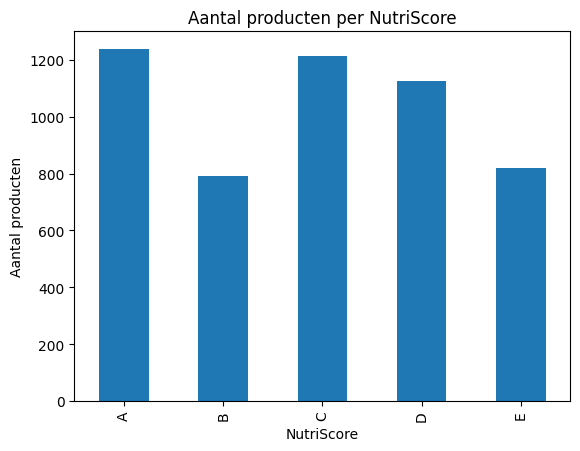

In [99]:
order = ["A", "B", "C", "D", "E"]

df["NutriScore"].value_counts().reindex(order).plot(kind="bar")
plt.title("Aantal producten per NutriScore")
plt.xlabel("NutriScore")
plt.ylabel("Aantal producten")
plt.show()

C:\Users\Luizv\AppData\Local\Temp\ipykernel_23420\952966046.py:14: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  counts["NutriScore"] = pd.Categorical(counts["NutriScore"], categories=order, ordered=True)
C:\Users\Luizv\AppData\Local\Temp\ipykernel_23420\952966046.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=counts, x="NutriScore", y="Count", palette="viridis")


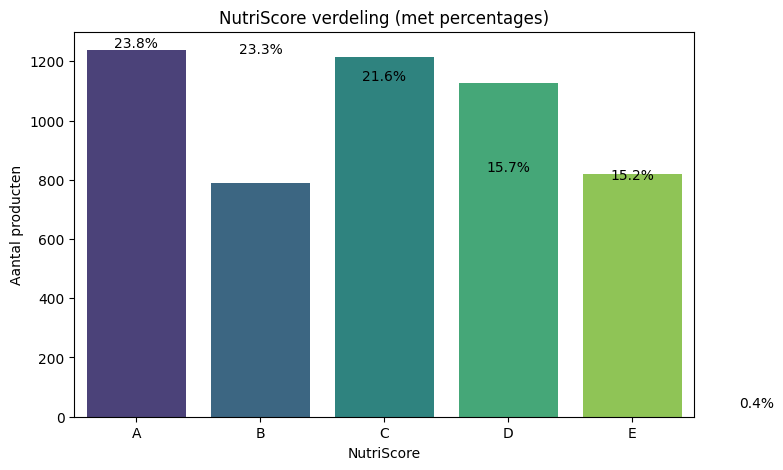

In [100]:
# 1. Data voorbereiden
df_plot = df.copy()
df_plot["NutriScore"] = df_plot["NutriScore"]

counts = df_plot["NutriScore"].value_counts().reset_index()
counts.columns = ["NutriScore", "Count"]

# 2. Percentages toevoegen
total = counts["Count"].sum()
counts["Percentage"] = (counts["Count"] / total * 100).round(1)

# 3. Sorteren (logische volgorde)
order = ["A", "B", "C", "D", "E"]
counts["NutriScore"] = pd.Categorical(counts["NutriScore"], categories=order, ordered=True)
counts = counts.sort_values("NutriScore")

# 4. Plot
plt.figure(figsize=(8,5))
ax = sns.barplot(data=counts, x="NutriScore", y="Count", palette="viridis")

# 5. Labels boven bars
for i, row in counts.iterrows():
    ax.text(
        i,
        row["Count"],
        f'{row["Percentage"]}%',
        ha="center",
        va="bottom"
    )

plt.title("NutriScore verdeling (met percentages)")
plt.xlabel("NutriScore")
plt.ylabel("Aantal producten")
plt.show()

In [101]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13512 entries, 0 to 13511
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   ProductId             13512 non-null  str           
 1   Name                  13512 non-null  str           
 2   Brand                 13512 non-null  str           
 3   CategoryCode          13512 non-null  str           
 4   Price                 13512 non-null  float64       
 5   Currency              13512 non-null  str           
 6   DiscountedPrice       13512 non-null  float64       
 7   PricePerUnitValue     13413 non-null  float64       
 8   PricePerUnitUnit      13413 non-null  str           
 9   PackageQuantityValue  13413 non-null  float64       
 10  PackageQuantityUnit   13413 non-null  str           
 11  PackageQuantityLabel  13512 non-null  str           
 12  ImageUrl              13436 non-null  str           
 13  NutriScore            5211 

In [102]:
df['NutritionPer100'].iloc[0]

'{"columns": ["Niet Bereid 100 g", "Niet Bereid (%RI) 10g"], "rows": [{"name": "Energie", "values": ["3051 kJ", "305 kJ (4.35%)"]}, {"name": "Kilocalorieën", "values": ["742 kcal", "74 kcal (4.35%)"]}, {"name": "Vetten waarvan", "values": ["82 g", "8.2 g (11.71%)"]}, {"name": "Verzadigde vetten", "values": ["50 g", "5 g (25%)"]}, {"name": "Koolhydraten waarvan", "values": ["0.5 g", "<0.5 g (0.23%)"]}, {"name": "Suikers", "values": ["0.5 g", "<0.5 g (0.59%)"]}, {"name": "Vezels", "values": ["<0.5 g", "<0.5 g"]}, {"name": "Eiwitten", "values": ["0.5 g", "<0.5 g (2.08%)"]}, {"name": "Zout", "values": ["<0.01 g", "<0.01 g (0.25%)"]}], "groups": ["Mineralen"], "footnote": "* Percentage dagelijkse waarden zijn gebaseerd op een 8400kJ/2000kcal dieet. Uw dagelijkse inname kan meer of minder zijn, afhankelijk van hoeveel calorieën u inneemt."}'

### Json parser
**Doel**
We willen voor de 100g deze waarde bijhouden
* Energie (kJ)
* Kilocalorieën (kcal)
* Vetten waarvan (g)
* Verzadigde vetten (g)
* Koolhydraten waarvan (g)
* Suikers (g)
* Vezels (g)
* Eiwitten (g)
* Zout (g)
* groups (Varchar(50))

In [103]:
import json 
def getNutritionGroups(json_string):

    if pd.isna(json_string):
        return None

    data = json.loads(json_string)

    return {
        f"{row['name']}_{row['values'][0].split()[1].lower() if len(row['values'][0].split()) > 1 else ''}".replace(" ", "_"):
        row["values"][0].split()[0].replace("<", "").replace(">", "")

        for row in data["rows"]
    }

In [104]:

for index, value in df['NutritionPer100'].items():

    nutrition = getNutritionGroups(value)
    
    print(nutrition)

    if nutrition:
        for key, val in nutrition.items():
            df.loc[index, key] = val


{'Energie_kj': '3051', 'Kilocalorieën_kcal': '742', 'Vetten_waarvan_g': '82', 'Verzadigde_vetten_g': '50', 'Koolhydraten_waarvan_g': '0.5', 'Suikers_g': '0.5', 'Vezels_g': '0.5', 'Eiwitten_g': '0.5', 'Zout_g': '0.01'}
{'Energie_kj': '489', 'Kilocalorieën_kcal': '118', 'Vetten_waarvan_g': '10', 'Verzadigde_vetten_g': '7', 'Koolhydraten_waarvan_g': '3.9', 'Suikers_g': '3.9', 'Eiwitten_g': '3.1', 'Zout_g': '0.11'}
{'Energie_kj': '364', 'Kilocalorieën_kcal': '87', 'Vetten_waarvan_g': '3.9', 'Verzadigde_vetten_g': '2.7', 'Koolhydraten_waarvan_g': '3.8', 'Suikers_g': '3.8', 'Eiwitten_g': '9.1', 'Zout_g': '0.08'}
{'Energie_kj': '500', 'Kilocalorieën_kcal': '119', 'Vetten_waarvan_g': '4.1', 'Verzadigde_vetten_g': '2.7', 'Koolhydraten_waarvan_g': '15.7', 'Suikers_g': '14.7', 'Eiwitten_g': '4.7', 'Zout_g': '0.11'}
{'Energie_kj': '552', 'Kilocalorieën_kcal': '131', 'Vetten_waarvan_g': '3', 'Verzadigde_vetten_g': '2', 'Koolhydraten_waarvan_g': '23.5', 'Suikers_g': '19.8', 'Vezels_g': '0.1', 'Eiwit

In [105]:
df.head()

,ProductId,Name,Brand,CategoryCode,Price,Currency,DiscountedPrice,PricePerUnitValue,PricePerUnitUnit,PackageQuantityValue,...,Mangaan_µg,Fosfor_µg,Ijzer_µg,Vitamine_B8_(Biotine)_x_ngm,Jood_g,Vitamin_B1_(thiamine)_g,Chroom_µg,Molybdeen_µg,Vitamine_B12(cobalamine)_x_ngm,Vitamine_B9_(foliumzuur)_x_ngm
0,F1981081800104400000,Karneboter,Delhaize,v2DAI,3.09,EUR,3.09,12.36,kg,250.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,F1981081800113700000,Yoghurt | Natuur | Melkspecialiteit,Danone,v2DAI,6.55,EUR,6.55,13.10,kg,500.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,F1981081800114000000,Verse Kaas | Petit Suisse | Mager | 20% v.g.,Danone,v2DAI,2.55,EUR,2.29,7.08,kg,360.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,F1981081800115600000,Kwark | Aardbei | Opgeklopt,Danio,v2DAI,2.59,EUR,2.59,10.36,kg,250.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,F1981081800132200000,Flan | Karamelsaus,La Laitière,v2DAI,2.79,EUR,2.79,6.98,kg,400.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Train en test split maken












In [106]:
df.shape

(13512, 106)

In [134]:
df_train = df.iloc[:, [2] + [13] + list(range(27, len(df.columns)))].fillna(0).dropna(subset=['NutriScore'])
df_test = df.iloc[:, [2] + list(range(27, len(df.columns)))].fillna(0)

In [135]:
df_train.head()

,Brand,NutriScore,Energie_kj,Kilocalorieën_kcal,Vetten_waarvan_g,Verzadigde_vetten_g,Koolhydraten_waarvan_g,Suikers_g,Vezels_g,Eiwitten_g,...,Mangaan_µg,Fosfor_µg,Ijzer_µg,Vitamine_B8_(Biotine)_x_ngm,Jood_g,Vitamin_B1_(thiamine)_g,Chroom_µg,Molybdeen_µg,Vitamine_B12(cobalamine)_x_ngm,Vitamine_B9_(foliumzuur)_x_ngm
0,Delhaize,E,3051,742,82,50,0.5,0.5,0.5,0.5,...,0,0,0,0,0,0,0,0,0,0
1,Danone,C,489,118,10,7,3.9,3.9,0,3.1,...,0,0,0,0,0,0,0,0,0,0
2,Danone,A,364,87,3.9,2.7,3.8,3.8,0,9.1,...,0,0,0,0,0,0,0,0,0,0
3,Danio,C,500,119,4.1,2.7,15.7,14.7,0,4.7,...,0,0,0,0,0,0,0,0,0,0
4,La Laitière,C,552,131,3,2,23.5,19.8,0.1,2.4,...,0,0,0,0,0,0,0,0,0,0


In [137]:
from sklearn.model_selection import train_test_split

X = df_train.drop(columns=['NutriScore'])
y = df_train['NutriScore']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [139]:
df_train.columns[2:-1]

Index(['Energie_kj', 'Kilocalorieën_kcal', 'Vetten_waarvan_g',
       'Verzadigde_vetten_g', 'Koolhydraten_waarvan_g', 'Suikers_g',
       'Vezels_g', 'Eiwitten_g', 'Zout_g', 'Calcium_mg',
       'Enkelvoudig_onverzadigde_vetten_g', 'Meervoudig_onverzadigde_vetten_g',
       'Vitamine_B12(cobalamine)_µg', 'Vitamine_D_(cholecalciferol)_mg',
       'polyolen_g', 'Zetmeel_g', 'Vitamin_B2_(riboflavine)_mg',
       'Vitamin_A_(retinol)_µg', 'Vitamine_D_(cholecalciferol)_µg',
       'Vitamine_E_(tocoferol)_g', 'Vitamine_B6_(pyridoxine)_mg',
       'Vitamine_E_(tocoferol)_mg', 'Vitamine_B9_(foliumzuur)_µg', 'Seleen_µg',
       'Jood_µg', 'Calcium_g', 'Vitamine_B12(cobalamine)_g',
       'Vitamine_C_(ascorbinezuur)_mg', 'Vitamin_B1_(thiamine)_mg',
       'Vitamin_A_(retinol)_mg', 'Fosfor_mg', 'Calcium_µg', 'Kalium_mg',
       'Ijzer_mg', 'Zink_mg', 'Magnesium_mg', 'Magnesium_µg', 'Ijzer_g',
       'Vitamine_C_(ascorbinezuur)_µg', 'Energie_', 'Kilocalorieën_',
       'Vetten_waarvan_', 'Verzadi

In [142]:
df_train[ingredient_cols] = (
    df_train[ingredient_cols]
    .replace(",", ".", regex=True)
    .apply(pd.to_numeric, errors="coerce")
)

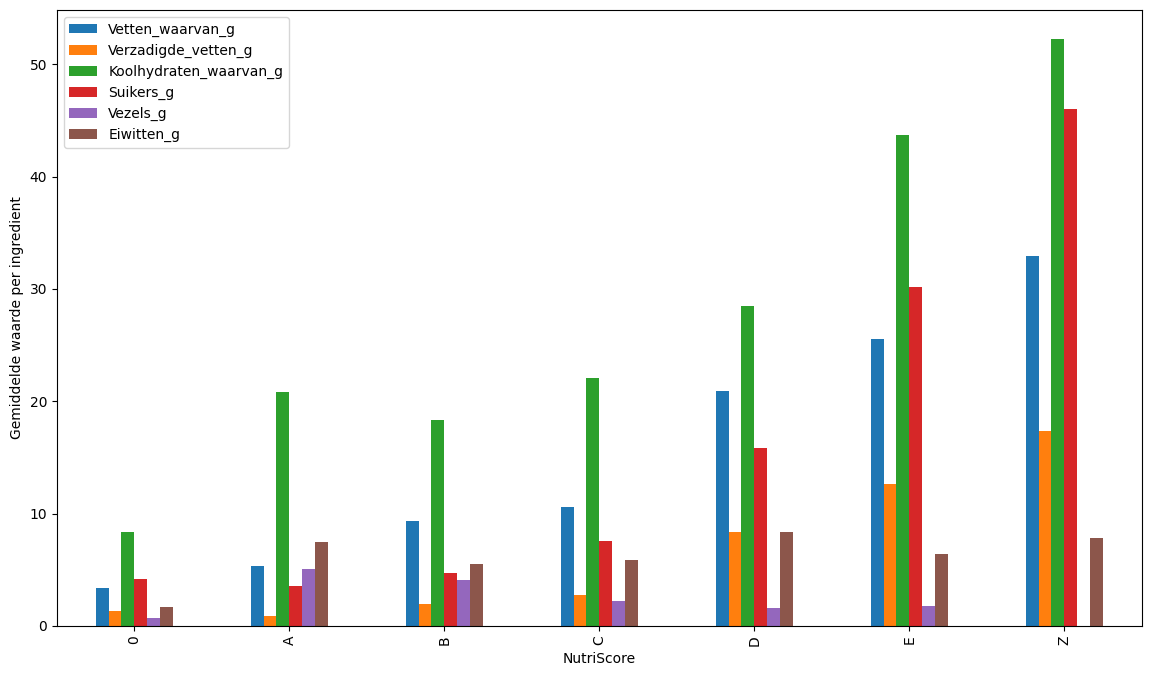

In [145]:
import matplotlib.pyplot as plt

# enkel numerieke ingredient kolommen
ingredient_cols = df_train.columns[4:10]
df_train[ingredient_cols] = (
    df_train[ingredient_cols]
    .replace(",", ".", regex=True)
    .apply(pd.to_numeric, errors="coerce")
)

# maak numeriek
df_train[ingredient_cols] = df_train[ingredient_cols].apply(pd.to_numeric)

# gemiddelde per NutriScore
grouped = df_train.groupby("NutriScore")[ingredient_cols].mean()

# plot
grouped.plot(kind='bar', figsize=(14,8))

plt.xlabel("NutriScore")
plt.ylabel("Gemiddelde waarde per ingredient")

plt.show()